#1. Data Preprocessing

Resource : https://download.bls.gov/pub/time.series/la/

In [2]:
import pandas as pd

df = pd.read_csv("la.data.64.County.txt", sep=r"\s+", engine="python")
print(df.head())
print(df.columns)

              series_id    year period value footnote_codes
0  LAUCN010010000000003  1990.0    M01   6.5           None
1  LAUCN010010000000003  1990.0    M02   6.4           None
2  LAUCN010010000000003  1990.0    M03   5.6           None
3  LAUCN010010000000003  1990.0    M04   6.6           None
4  LAUCN010010000000003  1990.0    M05   6.1           None
Index(['series_id', 'year', 'period', 'value', 'footnote_codes'], dtype='object')


In [3]:
df.shape

(324079, 5)

In [4]:
# only unemployment rate
df = df[df["series_id"].str[-3:] == "003"].copy()

# remove annual avg
df = df[df["period"] != "M13"].copy()

# FIPS
df["fips"] = df["series_id"].str[5:10]

# create the month column
df["month"] = df["period"].str[1:].astype(int)

# Data reframe into from 2015-2024
df = df[(df["year"] >= 2015) & (df["year"] <= 2024)].copy()
df["year"] = df["year"].astype(int)


df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1)
)

df = df[["fips", "date", "year", "month", "value"]].rename(
    columns={"value": "unemployment_rate"}
)

df = df.sort_values(["fips", "date"])

In [5]:
df.head(20)

,fips,date,year,month,unemployment_rate
325,01001,2015-01-01,2015,1,5.7
326,01001,2015-02-01,2015,2,5.4
327,01001,2015-03-01,2015,3,5.1
328,01001,2015-04-01,2015,4,4.7
329,01001,2015-05-01,2015,5,5.1
330,01001,2015-06-01,2015,6,5.5
331,01001,2015-07-01,2015,7,5.7
332,01001,2015-08-01,2015,8,5.4
333,01001,2015-09-01,2015,9,5.1
334,01001,2015-10-01,2015,10,5.0


In [6]:
# Filtering only into AL data
# Scalability of the research : We can delve into entire state wide research if we want.

df = df[df["fips"].str[:2] == "01"].copy()

In [7]:
df["fips"].nunique() # the number of alabama counties is 67

67

In [8]:
df.head()

,fips,date,year,month,unemployment_rate
325,01001,2015-01-01,2015,1,5.7
326,01001,2015-02-01,2015,2,5.4
327,01001,2015-03-01,2015,3,5.1
328,01001,2015-04-01,2015,4,4.7
329,01001,2015-05-01,2015,5,5.1


In [9]:
print(df.shape)
print("Number of counties:", df["fips"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())

print(df.isna().sum())

print("Duplicates:", df.duplicated(subset=["fips", "date"]).sum())

county_counts = df.groupby("fips").size()
print(county_counts.describe())
print(county_counts.head())

(8040, 5)
Number of counties: 67
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
fips                 0
date                 0
year                 0
month                0
unemployment_rate    0
dtype: int64
Duplicates: 0
count     67.0
mean     120.0
std        0.0
min      120.0
25%      120.0
50%      120.0
75%      120.0
max      120.0
dtype: float64
fips
01001    120
01003    120
01005    120
01007    120
01009    120
dtype: int64


In [10]:
df["unemployment_rate"] = pd.to_numeric(df["unemployment_rate"])

In [11]:
# Average Unemployment rate 2014-2025 of AL
df["unemployment_rate"].describe() # 4.7

,unemployment_rate
count,8040.000000
mean,4.701231
std,2.379446
min,1.300000
25%,3.000000
50%,4.100000
75%,5.800000
max,26.200000


In [12]:
state_monthly = (
    df.groupby("date", as_index=False)["unemployment_rate"]
      .mean()
      .rename(columns={"unemployment_rate": "avg_unemployment_rate"})
)

print(state_monthly.head())

        date  avg_unemployment_rate
0 2015-01-01               7.753731
1 2015-02-01               7.394030
2 2015-03-01               6.901493
3 2015-04-01               6.502985
4 2015-05-01               6.902985


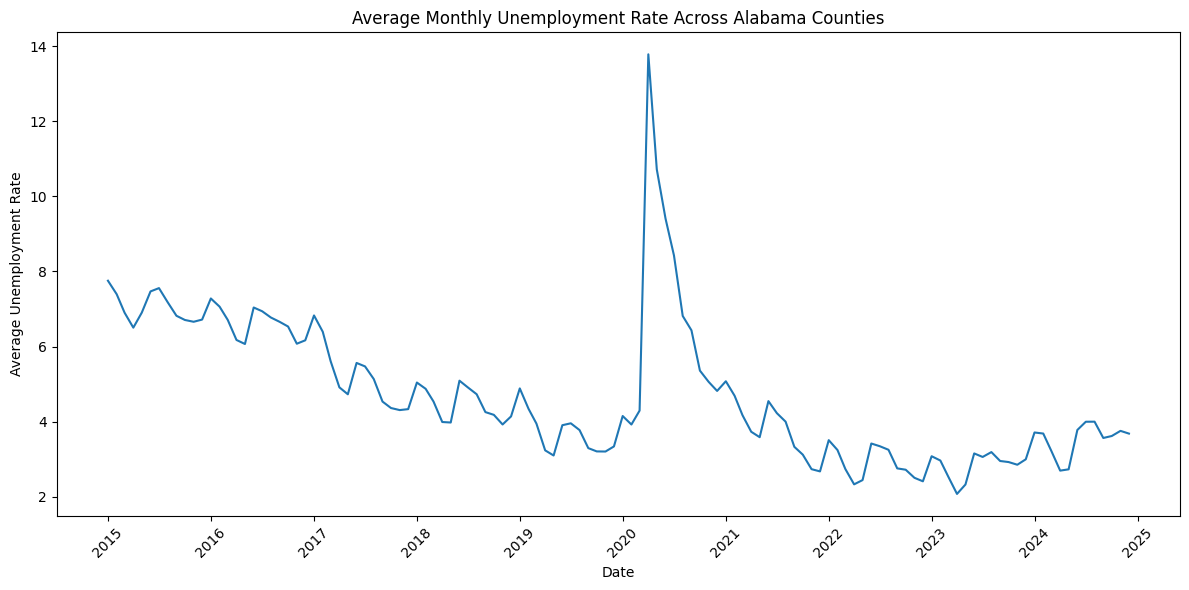

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(state_monthly["date"], state_monthly["avg_unemployment_rate"])
plt.title("Average Monthly Unemployment Rate Across Alabama Counties")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
area = pd.read_csv("la.area.txt", sep="\t")
area = area[area["area_code"].str.startswith("CN")].copy()
area.head()

,area_type_code,area_code,area_text,display_level,selectable,sort_sequence
1208,F,CN0100100000000,"Autauga County, AL",0,T,33
1209,F,CN0100300000000,"Baldwin County, AL",0,T,34
1210,F,CN0100500000000,"Barbour County, AL",0,T,35
1211,F,CN0100700000000,"Bibb County, AL",0,T,36
1212,F,CN0100900000000,"Blount County, AL",0,T,37


In [15]:
df.head()

,fips,date,year,month,unemployment_rate
325,01001,2015-01-01,2015,1,5.7
326,01001,2015-02-01,2015,2,5.4
327,01001,2015-03-01,2015,3,5.1
328,01001,2015-04-01,2015,4,4.7
329,01001,2015-05-01,2015,5,5.1


In [16]:
area["fips"] = area["area_code"].str[2:7]

In [17]:
area.head()

,area_type_code,area_code,area_text,display_level,selectable,sort_sequence,fips
1208,F,CN0100100000000,"Autauga County, AL",0,T,33,01001
1209,F,CN0100300000000,"Baldwin County, AL",0,T,34,01003
1210,F,CN0100500000000,"Barbour County, AL",0,T,35,01005
1211,F,CN0100700000000,"Bibb County, AL",0,T,36,01007
1212,F,CN0100900000000,"Blount County, AL",0,T,37,01009


In [18]:
df = df.merge(area[["fips", "area_text"]], on="fips", how="left")

In [19]:
df.head()

,fips,date,year,month,unemployment_rate,area_text
0,01001,2015-01-01,2015,1,5.7,"Autauga County, AL"
1,01001,2015-02-01,2015,2,5.4,"Autauga County, AL"
2,01001,2015-03-01,2015,3,5.1,"Autauga County, AL"
3,01001,2015-04-01,2015,4,4.7,"Autauga County, AL"
4,01001,2015-05-01,2015,5,5.1,"Autauga County, AL"


In [20]:
df["county_name"] = df["area_text"].str.replace(", AL", "", regex=False)
df = df.drop(columns=["area_text"])

df.head()

,fips,date,year,month,unemployment_rate,county_name
0,01001,2015-01-01,2015,1,5.7,Autauga County
1,01001,2015-02-01,2015,2,5.4,Autauga County
2,01001,2015-03-01,2015,3,5.1,Autauga County
3,01001,2015-04-01,2015,4,4.7,Autauga County
4,01001,2015-05-01,2015,5,5.1,Autauga County


## A1. County Comparison


In [21]:
county_rank = (
    df.groupby("county_name", as_index=False)["unemployment_rate"]
      .mean()
      .rename(columns={"unemployment_rate": "avg_unemployment_rate"})
      .sort_values("avg_unemployment_rate", ascending=False)
)

print(county_rank.head(15))
print(county_rank.tail(15))

          county_name  avg_unemployment_rate
52       Perry County               8.845000
65      Wilcox County               8.297500
31      Greene County               8.195000
42     Lowndes County               7.380000
23      Dallas County               6.925833
12      Clarke County               6.870000
49      Monroe County               6.455833
64  Washington County               6.148333
32        Hale County               6.058333
43       Macon County               5.975000
17     Conecuh County               5.938333
11     Choctaw County               5.719167
59      Sumter County               5.681667
6       Butler County               5.649167
2      Barbour County               5.407500
         county_name  avg_unemployment_rate
30     Geneva County               3.740833
24     DeKalb County               3.731667
15     Coffee County               3.724167
51     Morgan County               3.709167
0     Autauga County               3.591667
47   Marshall Co

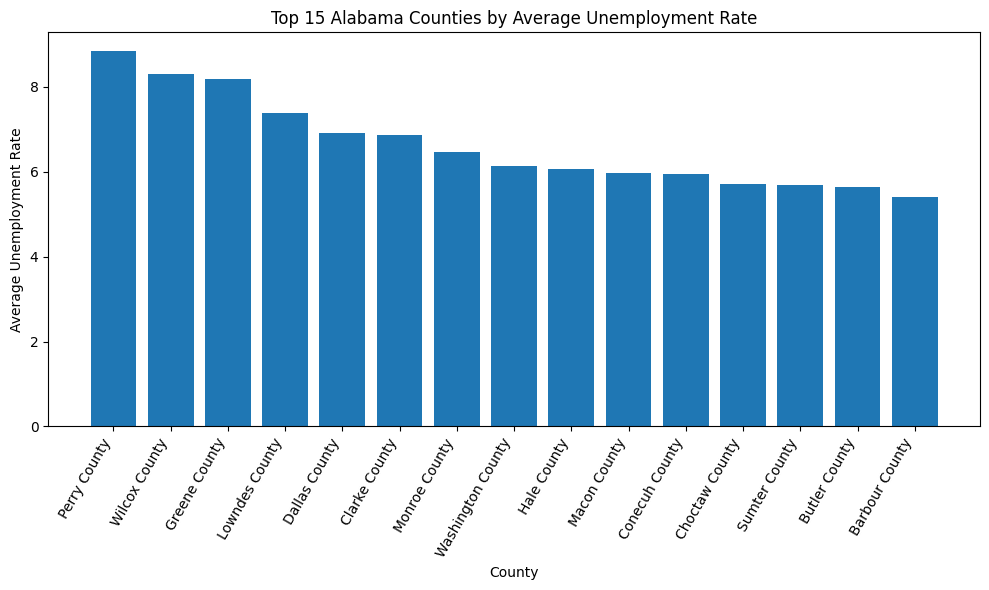

In [22]:
import matplotlib.pyplot as plt

top15_rank = county_rank.head(15)

plt.figure(figsize=(10,6))
plt.bar(top15_rank["county_name"], top15_rank["avg_unemployment_rate"])
plt.title("Top 15 Alabama Counties by Average Unemployment Rate")
plt.xlabel("County")
plt.ylabel("Average Unemployment Rate")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## A2. Volatility Analysis

In [23]:
county_vol = (
    df.groupby("county_name", as_index=False)["unemployment_rate"]
      .std()
      .rename(columns={"unemployment_rate": "unemployment_volatility"})
      .sort_values("unemployment_volatility", ascending=False)
)

print(county_vol.head(15))

          county_name  unemployment_volatility
52       Perry County                 3.463613
42     Lowndes County                 3.414418
31      Greene County                 3.386102
65      Wilcox County                 3.286168
32        Hale County                 2.829870
6       Butler County                 2.718718
64  Washington County                 2.701664
12      Clarke County                 2.654237
43       Macon County                 2.636915
23      Dallas County                 2.583903
17     Conecuh County                 2.442178
49      Monroe County                 2.404470
60   Talladega County                 2.341107
61  Tallapoosa County                 2.217942
3         Bibb County                 2.178312


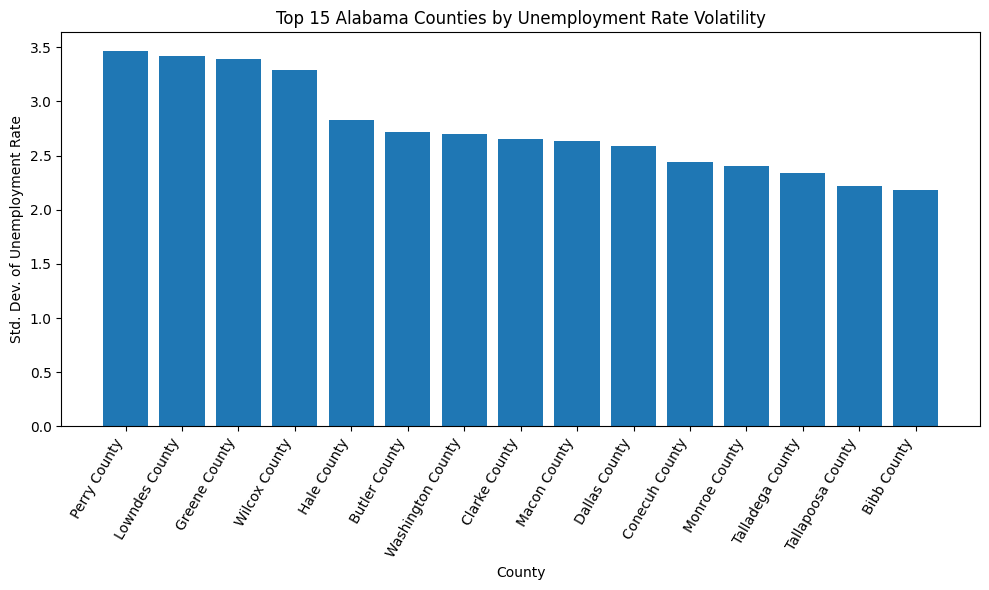

In [24]:
top15_vol = county_vol.head(15)

plt.figure(figsize=(10,6))
plt.bar(top15_vol["county_name"], top15_vol["unemployment_volatility"])
plt.title("Top 15 Alabama Counties by Unemployment Rate Volatility")
plt.xlabel("County")
plt.ylabel("Std. Dev. of Unemployment Rate")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

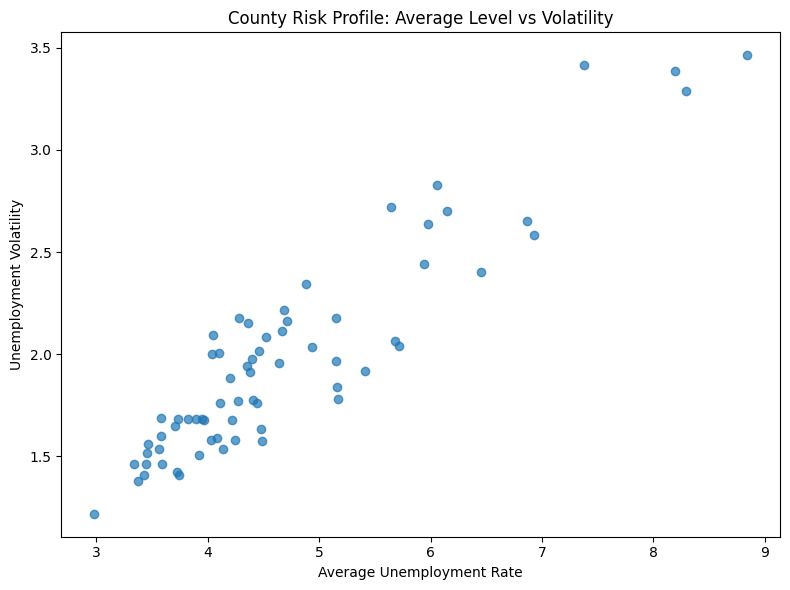

In [25]:
# Mean vs Volatility

county_profile = county_rank.merge(county_vol, on="county_name", how="inner")

plt.figure(figsize=(8,6))
plt.scatter(
    county_profile["avg_unemployment_rate"],
    county_profile["unemployment_volatility"],
    alpha=0.7
)
plt.xlabel("Average Unemployment Rate")
plt.ylabel("Unemployment Volatility")
plt.title("County Risk Profile: Average Level vs Volatility")
plt.tight_layout()
plt.show()

The scatter plot reveals a clear positive relationship between average unemployment levels and volatility across counties. Counties with higher average unemployment rates tend to also exhibit greater variability, indicating increased vulnerability to economic shocks. In contrast, counties with lower average unemployment generally show more stable labor market conditions. This pattern suggests that high-unemployment regions not only face persistent labor market challenges but also experience greater uncertainty over time.

## K-means

In [26]:
county_features = (
    df.groupby("county_name")
      .agg(
          avg_unemployment_rate=("unemployment_rate", "mean"),
          unemployment_volatility=("unemployment_rate", "std"),
          min_unemployment_rate=("unemployment_rate", "min"),
          max_unemployment_rate=("unemployment_rate", "max")
      )
      .reset_index()
)

print(county_features.head())

      county_name  avg_unemployment_rate  unemployment_volatility  \
0  Autauga County               3.591667                 1.460205   
1  Baldwin County               3.580833                 1.689179   
2  Barbour County               5.407500                 1.918384   
3     Bibb County               4.284167                 2.178312   
4   Blount County               3.428333                 1.408270   

   min_unemployment_rate  max_unemployment_rate  
0                    1.6                   11.1  
1                    1.6                   14.0  
2                    2.8                   10.1  
3                    1.6                   17.6  
4                    1.5                    9.1  


In [27]:
years = list(range(2015, 2025))
acs_list = []

for year in years:
    url = f"https://api.census.gov/data/{year}/acs/acs5"

    df_year = pd.read_json(
        url + "?get=NAME,B01003_001E,B19013_001E,B17001_002E,B17001_001E&for=county:*"
    )

    df_year.columns = df_year.iloc[0]
    df_year = df_year[1:]

    df_year["fips"] = df_year["state"] + df_year["county"]
    df_year["year"] = year

    # numeric
    for col in ["B01003_001E", "B19013_001E", "B17001_002E", "B17001_001E"]:
        df_year[col] = pd.to_numeric(df_year[col])

    df_year["poverty_rate"] = df_year["B17001_002E"] / df_year["B17001_001E"]

    df_year = df_year.rename(columns={
        "B01003_001E": "population",
        "B19013_001E": "median_income"
    })

    acs_list.append(df_year[["fips", "year", "population", "median_income", "poverty_rate"]])

acs = pd.concat(acs_list, ignore_index=True)

# Alabama only
acs = acs[acs["fips"].str.startswith("01")].copy()

acs.head()

,fips,year,population,median_income,poverty_rate
2111,01037,2015,11027,31212.0,0.192837
2112,01045,2015,49866,45028.0,0.191387
2113,01065,2015,15256,32714.0,0.267900
2114,01055,2015,103766,39220.0,0.196639
2115,01049,2015,71068,38192.0,0.186891


In [28]:
acs.shape

(670, 5)

In [29]:
acs.head(5)

,fips,year,population,median_income,poverty_rate
2111,01037,2015,11027,31212.0,0.192837
2112,01045,2015,49866,45028.0,0.191387
2113,01065,2015,15256,32714.0,0.267900
2114,01055,2015,103766,39220.0,0.196639
2115,01049,2015,71068,38192.0,0.186891


In [30]:
df["year"] = df["date"].dt.year
df = df.merge(acs, on=["fips", "year"], how="left")

df.head()

,fips,date,year,month,unemployment_rate,county_name,population,median_income,poverty_rate
0,01001,2015-01-01,2015,1,5.7,Autauga County,55221,51281.0,0.128794
1,01001,2015-02-01,2015,2,5.4,Autauga County,55221,51281.0,0.128794
2,01001,2015-03-01,2015,3,5.1,Autauga County,55221,51281.0,0.128794
3,01001,2015-04-01,2015,4,4.7,Autauga County,55221,51281.0,0.128794
4,01001,2015-05-01,2015,5,5.1,Autauga County,55221,51281.0,0.128794


# CBP

In [31]:
# CBP

In [32]:
import pandas as pd
import numpy as np
import requests
import zipfile
from io import BytesIO

# =====================================
# 2015 special case (different column names)
# =====================================
def process_cbp_2015():
    url = "https://www2.census.gov/programs-surveys/cbp/datasets/2015/cbp15co.zip"

    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with zipfile.ZipFile(BytesIO(r.content)) as z:
        with z.open("cbp15co.txt") as f:
            cbp = pd.read_csv(f)

    cbp.columns = [c.lower() for c in cbp.columns]

    cbp["fips"] = (
        cbp["fipstate"].astype(str).str.zfill(2) +
        cbp["fipscty"].astype(str).str.zfill(3)
    )

    cbp = cbp[cbp["fips"].str.startswith("01")].copy()
    cbp = cbp[cbp["fips"] != "01999"].copy()

    cbp["naics"] = cbp["naics"].astype(str).str.strip()
    cbp["est"] = pd.to_numeric(cbp["est"], errors="coerce")

    # total
    total = cbp[cbp["naics"] == "------"][["fips", "est"]].rename(columns={"est": "total_est"})

    # summary rows
    cbp_summary = cbp[
        cbp["naics"].isin(["31----","32----","33----","44----","45----","62----"])
    ]

    manu = cbp_summary[cbp_summary["naics"].isin(["31----","32----","33----"])]
    manu = manu.groupby("fips", as_index=False)["est"].sum().rename(columns={"est": "manu_est"})

    retail = cbp_summary[cbp_summary["naics"].isin(["44----","45----"])]
    retail = retail.groupby("fips", as_index=False)["est"].sum().rename(columns={"est": "retail_est"})

    health = cbp_summary[cbp_summary["naics"] == "62----"]
    health = health.groupby("fips", as_index=False)["est"].sum().rename(columns={"est": "health_est"})

    cbp_year = total.merge(manu, on="fips", how="left") \
                    .merge(retail, on="fips", how="left") \
                    .merge(health, on="fips", how="left")

    cbp_year = cbp_year.fillna(0)

    cbp_year["manu_share"] = cbp_year["manu_est"] / cbp_year["total_est"]
    cbp_year["retail_share"] = cbp_year["retail_est"] / cbp_year["total_est"]
    cbp_year["health_share"] = cbp_year["health_est"] / cbp_year["total_est"]

    cbp_year["year"] = 2015

    return cbp_year


# =====================================
# 2016+ standard case
# =====================================
def process_cbp_year(year):
    yy = str(year)[-2:]
    url = f"https://www2.census.gov/programs-surveys/cbp/datasets/{year}/cbp{yy}co.zip"

    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with zipfile.ZipFile(BytesIO(r.content)) as z:
        with z.open(f"cbp{yy}co.txt") as f:
            cbp = pd.read_csv(f)

    cbp["fips"] = (
        cbp["fipstate"].astype(str).str.zfill(2) +
        cbp["fipscty"].astype(str).str.zfill(3)
    )

    cbp = cbp[cbp["fips"].str.startswith("01")].copy()
    cbp = cbp[cbp["fips"] != "01999"].copy()

    cbp["naics"] = cbp["naics"].astype(str).str.strip()
    cbp["est"] = pd.to_numeric(cbp["est"], errors="coerce")

    total = cbp[cbp["naics"] == "------"][["fips", "est"]].rename(columns={"est": "total_est"})

    cbp_summary = cbp[
        cbp["naics"].isin(["31----","32----","33----","44----","45----","62----"])
    ]

    manu = cbp_summary[cbp_summary["naics"].isin(["31----","32----","33----"])]
    manu = manu.groupby("fips", as_index=False)["est"].sum().rename(columns={"est": "manu_est"})

    retail = cbp_summary[cbp_summary["naics"].isin(["44----","45----"])]
    retail = retail.groupby("fips", as_index=False)["est"].sum().rename(columns={"est": "retail_est"})

    health = cbp_summary[cbp_summary["naics"] == "62----"]
    health = health.groupby("fips", as_index=False)["est"].sum().rename(columns={"est": "health_est"})

    cbp_year = total.merge(manu, on="fips", how="left") \
                    .merge(retail, on="fips", how="left") \
                    .merge(health, on="fips", how="left")

    cbp_year = cbp_year.fillna(0)

    cbp_year["manu_share"] = cbp_year["manu_est"] / cbp_year["total_est"]
    cbp_year["retail_share"] = cbp_year["retail_est"] / cbp_year["total_est"]
    cbp_year["health_share"] = cbp_year["health_est"] / cbp_year["total_est"]

    cbp_year["year"] = year

    return cbp_year


# =====================================
# Combine all
# =====================================
cbp_list = []

# 2015
cbp_list.append(process_cbp_2015())
print("Processed 2015")

# 2016~2023
for year in range(2016, 2024):
    cbp_year = process_cbp_year(year)
    cbp_list.append(cbp_year)
    print(f"Processed {year}")

cbp_all = pd.concat(cbp_list, ignore_index=True)

# 2024 = copy 2023
cbp_2024 = cbp_all[cbp_all["year"] == 2023].copy()
cbp_2024["year"] = 2024
cbp_all = pd.concat([cbp_all, cbp_2024], ignore_index=True)

# =====================================
# merge
# =====================================
df = df.drop(columns=["total_est","manu_share","retail_share","health_share"], errors="ignore")

df["fips"] = df["fips"].astype(str).str.zfill(5)
df["year"] = df["year"].astype(int)

cbp_all["fips"] = cbp_all["fips"].astype(str).str.zfill(5)

df = df.merge(cbp_all, on=["fips","year"], how="left")

# =====================================
# check
# =====================================
print("\nRows per year:")
print(cbp_all["year"].value_counts().sort_index())

print("\nMissing:")
print(df[["manu_share","retail_share","health_share"]].isna().sum())

print("\nPreview:")
print(df.head())

Processed 2015
Processed 2016
Processed 2017
Processed 2018
Processed 2019
Processed 2020
Processed 2021
Processed 2022
Processed 2023

Rows per year:
year
2015    67
2016    67
2017    67
2018    67
2019    67
2020    67
2021    67
2022    67
2023    67
2024    67
Name: count, dtype: int64

Missing:
manu_share      0
retail_share    0
health_share    0
dtype: int64

Preview:
    fips       date  year  month  unemployment_rate     county_name  \
0  01001 2015-01-01  2015      1                5.7  Autauga County   
1  01001 2015-02-01  2015      2                5.4  Autauga County   
2  01001 2015-03-01  2015      3                5.1  Autauga County   
3  01001 2015-04-01  2015      4                4.7  Autauga County   
4  01001 2015-05-01  2015      5                5.1  Autauga County   

   population  median_income  poverty_rate  total_est  manu_est  retail_est  \
0       55221        51281.0      0.128794        844        24         169   
1       55221        51281.0      0.

In [33]:
df.head()

,fips,date,year,month,unemployment_rate,county_name,population,median_income,poverty_rate,total_est,manu_est,retail_est,health_est,manu_share,retail_share,health_share
0,01001,2015-01-01,2015,1,5.7,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
1,01001,2015-02-01,2015,2,5.4,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
2,01001,2015-03-01,2015,3,5.1,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
3,01001,2015-04-01,2015,4,4.7,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
4,01001,2015-05-01,2015,5,5.1,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019


In [34]:
df.head() # est : establishment, how many business?

,fips,date,year,month,unemployment_rate,county_name,population,median_income,poverty_rate,total_est,manu_est,retail_est,health_est,manu_share,retail_share,health_share
0,01001,2015-01-01,2015,1,5.7,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
1,01001,2015-02-01,2015,2,5.4,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
2,01001,2015-03-01,2015,3,5.1,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
3,01001,2015-04-01,2015,4,4.7,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019
4,01001,2015-05-01,2015,5,5.1,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019


# Clustering

In [35]:
# county level feature

import pandas as pd

features = df.groupby("fips").agg({
    "unemployment_rate": "mean",
    "poverty_rate": "mean",
    "median_income": "mean",
    "manu_share": "mean",
    "retail_share": "mean",
    "health_share": "mean"
}).reset_index()

features.head()

,fips,unemployment_rate,poverty_rate,median_income,manu_share,retail_share,health_share
0,01001,3.591667,0.131563,60849.3,0.027152,0.192800,0.107452
1,01003,3.580833,0.108371,61939.8,0.030384,0.174642,0.092106
2,01005,5.407500,0.262368,36845.5,0.052908,0.194856,0.086009
3,01007,4.284167,0.179239,47516.3,0.056738,0.179625,0.082153
4,01009,3.428333,0.144942,52196.8,0.057910,0.178081,0.089583


In [36]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = features.drop(columns=["fips"])
X_scaled = scaler.fit_transform(X)

In [37]:
# K-means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(X_scaled)

features.head()

,fips,unemployment_rate,poverty_rate,median_income,manu_share,retail_share,health_share,cluster
0,01001,3.591667,0.131563,60849.3,0.027152,0.192800,0.107452,0
1,01003,3.580833,0.108371,61939.8,0.030384,0.174642,0.092106,0
2,01005,5.407500,0.262368,36845.5,0.052908,0.194856,0.086009,1
3,01007,4.284167,0.179239,47516.3,0.056738,0.179625,0.082153,2
4,01009,3.428333,0.144942,52196.8,0.057910,0.178081,0.089583,0


In [38]:
cluster_summary = features.groupby("cluster")[
    ["unemployment_rate", "poverty_rate", "median_income",
     "manu_share", "retail_share", "health_share"]
].mean()

print(cluster_summary)

         unemployment_rate  poverty_rate  median_income  manu_share  \
cluster                                                               
0                 3.805049      0.147025   58162.129412    0.039131   
1                 6.433490      0.273943   33940.256250    0.049061   
2                 4.334142      0.185488   44913.861765    0.058034   

         retail_share  health_share  
cluster                              
0            0.170188      0.098826  
1            0.225833      0.093213  
2            0.201277      0.103575  


In [39]:
cluster_summary.head()

,unemployment_rate,poverty_rate,median_income,manu_share,retail_share,health_share
cluster,,,,,,
0,3.805049,0.147025,58162.129412,0.039131,0.170188,0.098826
1,6.433490,0.273943,33940.256250,0.049061,0.225833,0.093213
2,4.334142,0.185488,44913.861765,0.058034,0.201277,0.103575


In [40]:
print(cluster_summary)

         unemployment_rate  poverty_rate  median_income  manu_share  \
cluster                                                               
0                 3.805049      0.147025   58162.129412    0.039131   
1                 6.433490      0.273943   33940.256250    0.049061   
2                 4.334142      0.185488   44913.861765    0.058034   

         retail_share  health_share  
cluster                              
0            0.170188      0.098826  
1            0.225833      0.093213  
2            0.201277      0.103575  


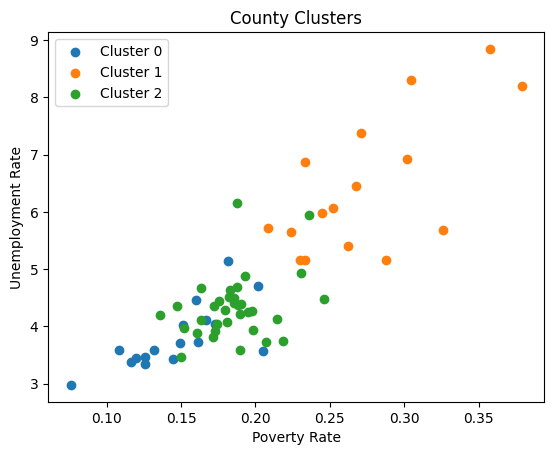

In [41]:
import matplotlib.pyplot as plt

plt.figure()

for c in features["cluster"].unique():
    subset = features[features["cluster"] == c]
    plt.scatter(
        subset["poverty_rate"],
        subset["unemployment_rate"],
        label=f"Cluster {c}"
    )

plt.xlabel("Poverty Rate")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.title("County Clusters")
plt.show()

In [42]:
# check columns first
print(df.columns)

# if cluster is not in df, merge it back from features
if "cluster" not in df.columns:
    df = df.merge(features[["fips", "cluster"]], on="fips", how="left")

# run ANOVA
from scipy.stats import f_oneway

group0 = df[df["cluster"] == 0]["unemployment_rate"]
group1 = df[df["cluster"] == 1]["unemployment_rate"]
group2 = df[df["cluster"] == 2]["unemployment_rate"]

f_stat, p_value = f_oneway(group0, group1, group2)

print("F-stat:", f_stat)
print("p-value:", p_value)

Index(['fips', 'date', 'year', 'month', 'unemployment_rate', 'county_name',
       'population', 'median_income', 'poverty_rate', 'total_est', 'manu_est',
       'retail_est', 'health_est', 'manu_share', 'retail_share',
       'health_share'],
      dtype='object')
F-stat: 850.3965057455293
p-value: 0.0


The ANOVA results indicate statistically significant differences in unemployment rates across clusters (F ≈ 850, p < 0.001), confirming that the clustering captures meaningful heterogeneity in labor market conditions.

In [43]:
# Full Cluster Assignment

In [44]:
# 1. county name mapping from df
county_map = df[["fips", "county_name"]].drop_duplicates()

# 2. full cluster assignment
cluster_assignment = features.merge(county_map, on="fips", how="left")

# 3. add readable labels
cluster_label_map = {
    0: "Stable",
    1: "Distressed",
    2: "Industrial"
}

cluster_assignment["cluster_label"] = cluster_assignment["cluster"].map(cluster_label_map)

# 4. keep only useful columns
cluster_assignment = cluster_assignment[
    ["county_name", "fips", "cluster", "cluster_label"]
].sort_values(["cluster", "county_name"]).reset_index(drop=True)

# 5. preview
print(cluster_assignment.head(20))

          county_name   fips  cluster cluster_label
0      Autauga County  01001        0        Stable
1      Baldwin County  01003        0        Stable
2       Blount County  01009        0        Stable
3       Coffee County  01031        0        Stable
4     Crenshaw County  01041        0        Stable
5       Elmore County  01051        0        Stable
6        Henry County  01067        0        Stable
7    Jefferson County  01073        0        Stable
8          Lee County  01081        0        Stable
9    Limestone County  01083        0        Stable
10     Madison County  01089        0        Stable
11      Mobile County  01097        0        Stable
12  Montgomery County  01101        0        Stable
13      Morgan County  01103        0        Stable
14      Shelby County  01117        0        Stable
15   St. Clair County  01115        0        Stable
16  Tuscaloosa County  01125        0        Stable
17     Barbour County  01005        1    Distressed
18     Bullo

In [45]:
cluster_assignment

,county_name,fips,cluster,cluster_label
0,Autauga County,01001,0,Stable
1,Baldwin County,01003,0,Stable
2,Blount County,01009,0,Stable
3,Coffee County,01031,0,Stable
4,Crenshaw County,01041,0,Stable
...,...,...,...,...
62,Talladega County,01121,2,Industrial
63,Tallapoosa County,01123,2,Industrial
64,Walker County,01127,2,Industrial
65,Washington County,01129,2,Industrial


In [46]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=cluster_assignment)

https://docs.google.com/spreadsheets/d/1sGQCd4sDnBN6l2GwH7yCI2jjJ1QaGzyqiz_D5HKOfHQ/edit#gid=0


## A3. Volatility Analysis - Covid

In [47]:
df = df.merge(features[["fips", "cluster"]], on="fips", how="left")

In [50]:
df.head()

,fips,date,year,month,unemployment_rate,county_name,population,median_income,poverty_rate,total_est,manu_est,retail_est,health_est,manu_share,retail_share,health_share,cluster_x,cluster_y
0,01001,2015-01-01,2015,1,5.7,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019,0,0
1,01001,2015-02-01,2015,2,5.4,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019,0,0
2,01001,2015-03-01,2015,3,5.1,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019,0,0
3,01001,2015-04-01,2015,4,4.7,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019,0,0
4,01001,2015-05-01,2015,5,5.1,Autauga County,55221,51281.0,0.128794,844,24,169,93,0.028436,0.200237,0.11019,0,0


In [51]:
(df["cluster_x"] == df["cluster_y"]).all()

np.True_

In [52]:
df = df.drop(columns=["cluster_y"])
df = df.rename(columns={"cluster_x": "cluster"})

In [53]:
pre = df[df["year"] <= 2019].groupby("cluster")["unemployment_rate"].mean()
covid = df[df["year"] == 2020].groupby("cluster")["unemployment_rate"].mean()

print(covid - pre)

cluster
0    1.396275
1    2.611042
2    1.092451
Name: unemployment_rate, dtype: float64


In [54]:
# peak comparison
df[df["year"] == 2020].groupby("cluster")["unemployment_rate"].mean()

,unemployment_rate
cluster,
0,5.757353
1,9.756250
2,6.190686


In [55]:
# recovery comparison
df[df["year"] >= 2022].groupby("cluster")["unemployment_rate"].mean()

,unemployment_rate
cluster,
0,2.501797
1,4.314757
2,2.800163


In [56]:
# Shock
pre = df[df["year"] <= 2019].groupby("cluster")["unemployment_rate"].mean()
covid = df[df["year"] == 2020].groupby("cluster")["unemployment_rate"].mean()
shock = covid - pre

# Peak
peak = df[df["year"] == 2020].groupby("cluster")["unemployment_rate"].mean()

# Recovery
recovery = df[df["year"] >= 2022].groupby("cluster")["unemployment_rate"].mean()



#merge
plot_df = pd.DataFrame({
    "Shock": shock,
    "Peak": peak,
    "Recovery": recovery
})

plot_df = plot_df.reset_index()
print(plot_df)

# bar graph
plot_df = pd.DataFrame({
    "Shock": shock,
    "Peak": peak,
    "Recovery": recovery
})

plot_df = plot_df.reset_index()
print(plot_df)

   cluster     Shock      Peak  Recovery
0        0  1.396275  5.757353  2.501797
1        1  2.611042  9.756250  4.314757
2        2  1.092451  6.190686  2.800163
   cluster     Shock      Peak  Recovery
0        0  1.396275  5.757353  2.501797
1        1  2.611042  9.756250  4.314757
2        2  1.092451  6.190686  2.800163


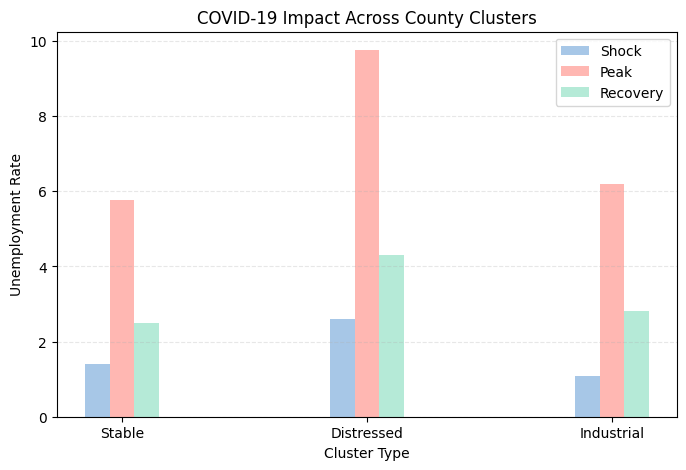

In [57]:
import matplotlib.pyplot as plt
import numpy as np

cluster_labels = {
    0: "Stable",
    1: "Distressed",
    2: "Industrial"
}

labels = [cluster_labels[c] for c in plot_df["cluster"]]

x = np.arange(len(labels))
width = 0.1

plt.figure(figsize=(8,5))

colors = ["#A7C7E7", "#FFB7B2", "#B5EAD7"]

plt.bar(x - width, plot_df["Shock"], width, color=colors[0], label="Shock")
plt.bar(x, plot_df["Peak"], width, color=colors[1], label="Peak")
plt.bar(x + width, plot_df["Recovery"], width, color=colors[2], label="Recovery")

plt.xticks(x, labels)

plt.xlabel("Cluster Type")
plt.ylabel("Unemployment Rate")
plt.title("COVID-19 Impact Across County Clusters")

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

This figure presents the differential impact of COVID-19 across county clusters. The “Distressed” cluster exhibits the highest increase in unemployment during the shock period, as well as the highest peak and slowest recovery. In contrast, the “Stable” cluster shows relatively smaller disruptions and faster recovery, while the “Industrial” cluster demonstrates moderate impact and resilience.

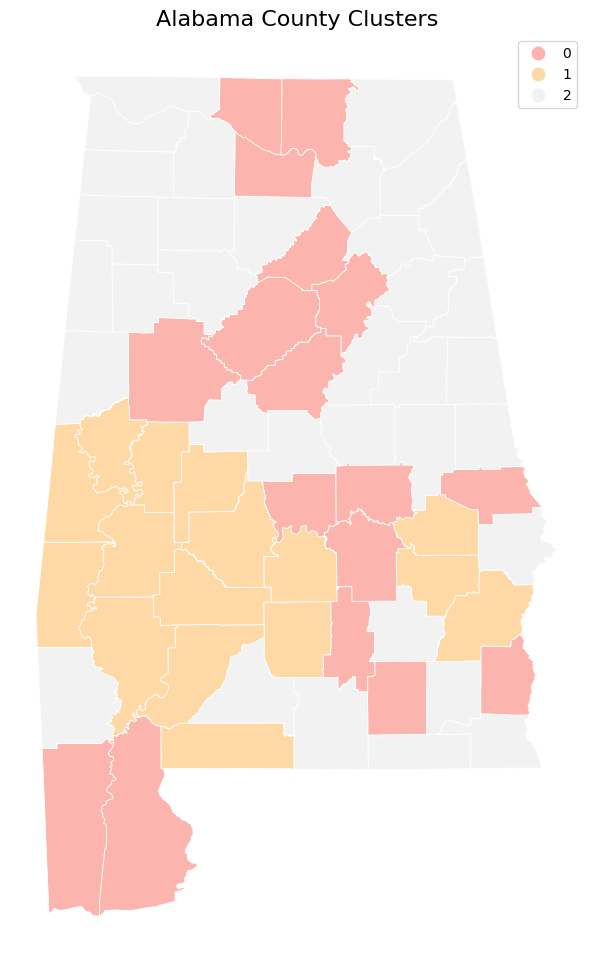

In [58]:
# If needed:
# !pip install geopandas mapclassify

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Alabama county shapefile from Census TIGER
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip"
)

# 2) Keep Alabama only (STATEFP = 01)
al_counties = counties[counties["STATEFP"] == "01"].copy()

# 3) Build 5-digit county FIPS
al_counties["fips"] = al_counties["STATEFP"] + al_counties["COUNTYFP"]

# 4) Merge cluster labels from your features dataframe
# features must contain: fips, cluster
features["fips"] = features["fips"].astype(str).str.zfill(5)

map_df = al_counties.merge(
    features[["fips", "cluster"]],
    on="fips",
    how="left"
)

# 5) readable cluster names
cluster_name_map = {
    0: "Stable",
    1: "Distressed",
    2: "Industrial"
}
map_df["cluster_name"] = map_df["cluster"].map(cluster_name_map)

# 6) Plot
fig, ax = plt.subplots(figsize=(10, 12))

map_df.plot(
    column="cluster",
    categorical=True,
    legend=True,
    cmap="Pastel1",
    linewidth=0.6,
    edgecolor="white",
    ax=ax,
    missing_kwds={"color": "#eeeeee", "label": "Missing"}
)

ax.set_title("Alabama County Clusters", fontsize=16)
ax.axis("off")

plt.show()

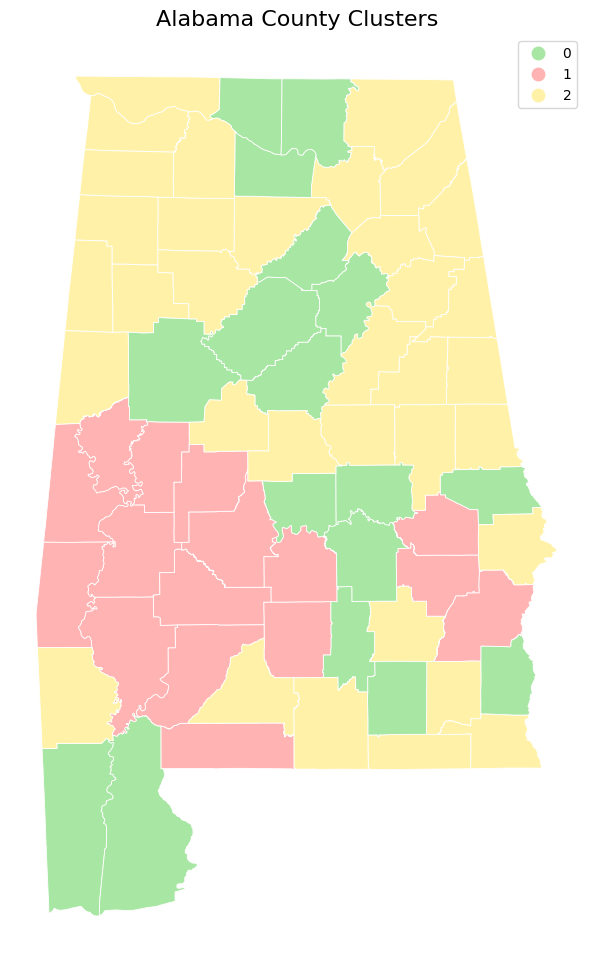

In [59]:
### Color change

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

area_colors = [
    "#A8E6A3",  # Stable (soft green)
    "#FFB3B3",  # Distressed (soft red/pink)
    "#FFF2A8"   # Industrial (soft yellow)
]

cmap = ListedColormap(area_colors)

fig, ax = plt.subplots(figsize=(10, 12))

map_df.plot(
    column="cluster",
    categorical=True,
    cmap=cmap,
    linewidth=0.6,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Alabama County Clusters", fontsize=16)
ax.axis("off")

plt.show()

#A4. County

In [60]:
features.groupby("cluster")["fips"].apply(list)

,fips
cluster,
0,"[01001, 01003, 01009, 01031, 01041, 01051, 010..."
1,"[01005, 01011, 01013, 01023, 01025, 01047, 010..."
2,"[01007, 01015, 01017, 01019, 01021, 01027, 010..."


In [61]:
# fips + county_name unique mapping
county_map = df[["fips", "county_name"]].drop_duplicates()

features_named = features.merge(county_map, on="fips", how="left")
cluster_counties = features_named.groupby("cluster")["county_name"].apply(list)

for c in cluster_counties.index:
    print(f"\nCluster {c}:")
    print(cluster_counties[c])


Cluster 0:
['Autauga County', 'Baldwin County', 'Blount County', 'Coffee County', 'Crenshaw County', 'Elmore County', 'Henry County', 'Jefferson County', 'Lee County', 'Limestone County', 'Madison County', 'Mobile County', 'Montgomery County', 'Morgan County', 'St. Clair County', 'Shelby County', 'Tuscaloosa County']

Cluster 1:
['Barbour County', 'Bullock County', 'Butler County', 'Choctaw County', 'Clarke County', 'Dallas County', 'Escambia County', 'Greene County', 'Hale County', 'Lowndes County', 'Macon County', 'Marengo County', 'Monroe County', 'Perry County', 'Sumter County', 'Wilcox County']

Cluster 2:
['Bibb County', 'Calhoun County', 'Chambers County', 'Cherokee County', 'Chilton County', 'Clay County', 'Cleburne County', 'Colbert County', 'Conecuh County', 'Coosa County', 'Covington County', 'Cullman County', 'Dale County', 'DeKalb County', 'Etowah County', 'Fayette County', 'Franklin County', 'Geneva County', 'Houston County', 'Jackson County', 'Lamar County', 'Lauderdale

# Prediction

In [62]:
# aggregate - yearly
model_df = df.groupby(["fips","year"]).agg({
    "unemployment_rate": "mean",
    "poverty_rate": "mean",
    "median_income": "mean",
    "manu_share": "mean",
    "retail_share": "mean",
    "health_share": "mean"
}).reset_index()

model_df.head()

,fips,year,unemployment_rate,poverty_rate,median_income,manu_share,retail_share,health_share
0,01001,2015,5.216667,0.128794,51281.0,0.028436,0.200237,0.110190
1,01001,2016,5.083333,0.122660,53099.0,0.025852,0.197415,0.111633
2,01001,2017,4.000000,0.137157,55317.0,0.026467,0.193326,0.109321
3,01001,2018,3.641667,0.153784,58786.0,0.029240,0.192982,0.102924
4,01001,2019,2.916667,0.151852,58731.0,0.024221,0.198385,0.102653


In [63]:
# Define X, y
feature_cols = [
    "poverty_rate",
    "median_income",
    "manu_share",
    "retail_share",
    "health_share"
]

X = model_df[feature_cols]
y = model_df["unemployment_rate"]

In [64]:
# train, test split
train = model_df[model_df["year"] <= 2021]
test = model_df[model_df["year"] >= 2022]

X_train = train[feature_cols]
y_train = train["unemployment_rate"]

X_test = test[feature_cols]
y_test = test["unemployment_rate"]

In [65]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, rf_pred))

RF MAE: 1.3044089966832493


In [66]:
# XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, xgb_pred))

XGB MAE: 1.2701937495179436


<Axes: >

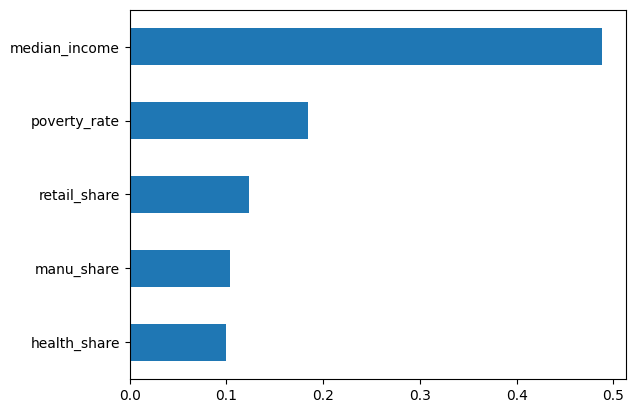

In [67]:
# Feature Importance - rf

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols)
rf_importance.sort_values().plot(kind="barh")

<Axes: >

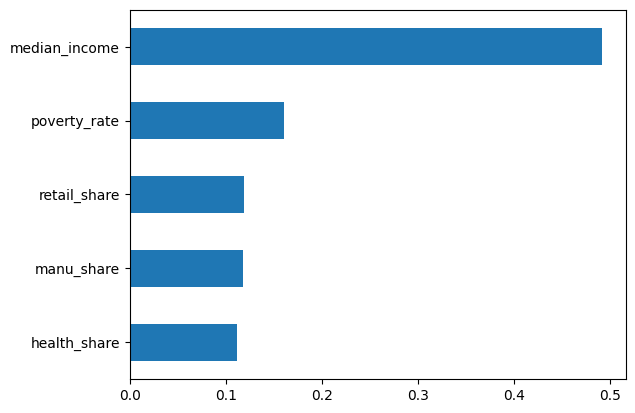

In [68]:
# Feature Importance - XGBoost

xgb_importance = pd.Series(xgb.feature_importances_, index=feature_cols)
xgb_importance.sort_values().plot(kind="barh")

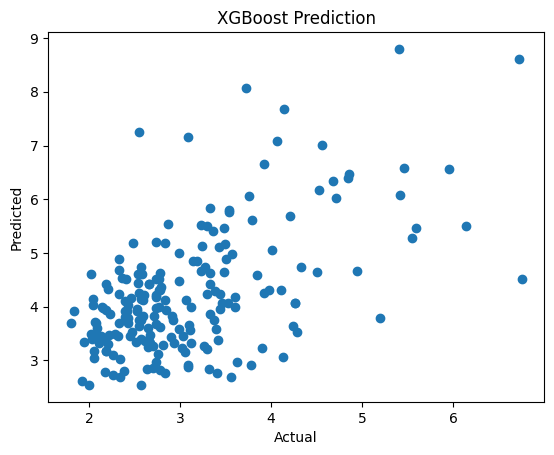

In [69]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Prediction")

plt.show()

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.3044089966832493
RMSE: 1.4908820913128158
